# 決定木モデルを作成
 - サンプルとして決定木で1着になる「確率」を予測して確率の一番高い馬にベットすることを考える
 - 2023年のレース結果データを用いて学習し, 2024年のデータを用いて検証を行う

## Import

In [ ]:
import numpy as np
import pandas as pd
import joblib

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import roc_auc_score

import seaborn as sns
import matplotlib.pyplot as plt

## Setting

In [ ]:
# Path
input_path = "./input_data/"

# Figure Size
plt.rcParams["figure.figsize"] = (15.0, 10.0)

## Read Data

In [ ]:
col_list = [
    "race_id", "year", "month", "day", "times",
    "place", "daily", "race_num", "horse", "jockey_id",
    "horse_N", "waku_num", "horse_num", "class_code", "track_code",
    "corner_num", "dist", "state", "weather", "age_code",
    "sex", "age", "basis_weight", "blinker", "weight",
    "inc_dec", "weight_code", "win_odds", "rank", "time_diff",
    "time", "corner1_rank", "corner2_rank", "corner3_rank", "corner4_rank",
    "last_3F_time", "last_3F_rank", "Ave_3F", "PCI", "last_3F_time_diff",
    "leg", "pop", "prize", "error_code",
    "father", "mother", "id"
]

train = pd.read_csv(input_path+"record_data_2023.csv", encoding="shift_jis", names=col_list, low_memory=False)
valid = pd.read_csv(input_path+"record_data_2024.csv", encoding="shift_jis", names=col_list, low_memory=False)

In [ ]:
train.head()

,race_id,year,month,day,times,place,daily,race_num,horse,jockey_id,...,Ave_3F,PCI,last_3F_time_diff,leg,pop,prize,error_code,father,mother,id
0,202307220101010101,23,7,22,1,札幌,1,1,ウィスピースノー,1095,...,35.8,53.8,0.8,後方,5.0,55,0,ワールドエース,ハイリマイリ,2021100648
1,202307220101010102,23,7,22,1,札幌,1,1,ロードスタウト,1157,...,35.6,51.4,0.6,中団,7.0,0,0,ロードカナロア,フィラデルフィア,2021100159
2,202307220101010103,23,7,22,1,札幌,1,1,コミックガール,1197,...,35.6,50.8,0.6,中団,4.0,0,0,シルバーステート,コイクレナイ,2021100265
3,202307220101010104,23,7,22,1,札幌,1,1,デビルシズカチャン,5339,...,35.3,51.1,0.3,先行,3.0,83,0,ベストウォーリア,シシリアンブリーズ,2021105553
4,202307220101010105,23,7,22,1,札幌,1,1,サトミノキラリ,1170,...,35.2,52.6,0.2,先行,1.0,550,0,ビッグアーサー,パレード,2021101429


In [ ]:
train.shape

(47672, 47)

## EDA
 本来はここで皆さんがEDAを行い, データ理解と戦略の示唆を見つける.

## Make Feature
 ここでは例として前走の着順を特徴量として作成する. **ここが皆さんの腕の見せ所**.

In [ ]:
# データをtrainとvalidで縦積み
dat = pd.concat([train, valid], axis=0)

# 馬ごとに時系列順に並べ替え
features = dat.sort_values(["id", "race_id"]).copy()
features[["year", "month", "day", "horse", "rank"]].head(20)

,year,month,day,horse,rank
39412,23,4,9,シベリアンタイガー,7
13831,23,4,30,シベリアンタイガー,10
14539,23,5,14,シベリアンタイガー,9
39935,23,6,3,シベリアンタイガー,8
41099,23,6,25,シベリアンタイガー,11
30310,23,7,9,シベリアンタイガー,11
41816,23,9,18,シベリアンタイガー,9
34088,23,10,7,シベリアンタイガー,11
35257,23,10,29,シベリアンタイガー,9
18569,23,11,11,シベリアンタイガー,8


In [ ]:
# 馬ごとに前レース結果を付与
features["rank_last"] = features.groupby("id")[["rank"]].shift(1)

In [ ]:
features[["year", "month", "day", "horse", "rank", "rank_last"]].head(20)

,year,month,day,horse,rank,rank_last
39412,23,4,9,シベリアンタイガー,7,NaN
13831,23,4,30,シベリアンタイガー,10,7.0
14539,23,5,14,シベリアンタイガー,9,10.0
39935,23,6,3,シベリアンタイガー,8,9.0
41099,23,6,25,シベリアンタイガー,11,8.0
30310,23,7,9,シベリアンタイガー,11,11.0
41816,23,9,18,シベリアンタイガー,9,11.0
34088,23,10,7,シベリアンタイガー,11,9.0
35257,23,10,29,シベリアンタイガー,9,11.0
18569,23,11,11,シベリアンタイガー,8,9.0


In [ ]:
# 馬ごとにデータ上の最初のレースは前レース結果が無いので0埋め：本来は新馬戦のみ欠損となるべき
features["rank_last"] = features["rank_last"].fillna(0)

In [ ]:
features[["year", "month", "day", "horse", "rank", "rank_last"]].head(20)

,year,month,day,horse,rank,rank_last
39412,23,4,9,シベリアンタイガー,7,0.0
13831,23,4,30,シベリアンタイガー,10,7.0
14539,23,5,14,シベリアンタイガー,9,10.0
39935,23,6,3,シベリアンタイガー,8,9.0
41099,23,6,25,シベリアンタイガー,11,8.0
30310,23,7,9,シベリアンタイガー,11,11.0
41816,23,9,18,シベリアンタイガー,9,11.0
34088,23,10,7,シベリアンタイガー,11,9.0
35257,23,10,29,シベリアンタイガー,9,11.0
18569,23,11,11,シベリアンタイガー,8,9.0


In [ ]:
# train, validに結合
print(train.shape)
train = pd.merge(train, features[["id", "race_id", "rank_last"]], how="inner", on=["id", "race_id"])
print(train.shape)

print(valid.shape)
valid = pd.merge(valid, features[["id", "race_id", "rank_last"]], how="inner", on=["id", "race_id"])
print(valid.shape)

(47672, 47)
(47672, 48)
(47181, 47)
(47181, 48)


## Make Model：Decision Tree
 - 作成した特徴量のrank_lastとageを利用して決定木を学習する
 - 決定木モデルの作成. 各種パラメータは下記を参考にして下さい.
   - https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

In [ ]:
train_x = train[["age", "rank_last"]].copy()
train_y = (train["rank"] == 1) + 0
col_name = list(train_x.columns.values)

valid_x = valid[["age", "rank_last"]].copy()
valid_y = (valid["rank"] == 1) + 0

一旦作って可視化してみる

In [ ]:
tree_model = DecisionTreeClassifier(
    criterion="gini",            # Entropy基準の場合は"entropy”
    splitter="best",             # 分割をランダムで行う場合は"random"
    random_state=17,             # 同じ分割スコアの時にランダムに選ぶseedを固定
    max_depth=3,                 # 決定木の深さの最大値
    min_samples_split=500,       # 分割する最小データ数
    min_samples_leaf=100         # 末端ノードに該当する最小サンプル数
)
tree_model = tree_model.fit(train_x, train_y)

### Visualization

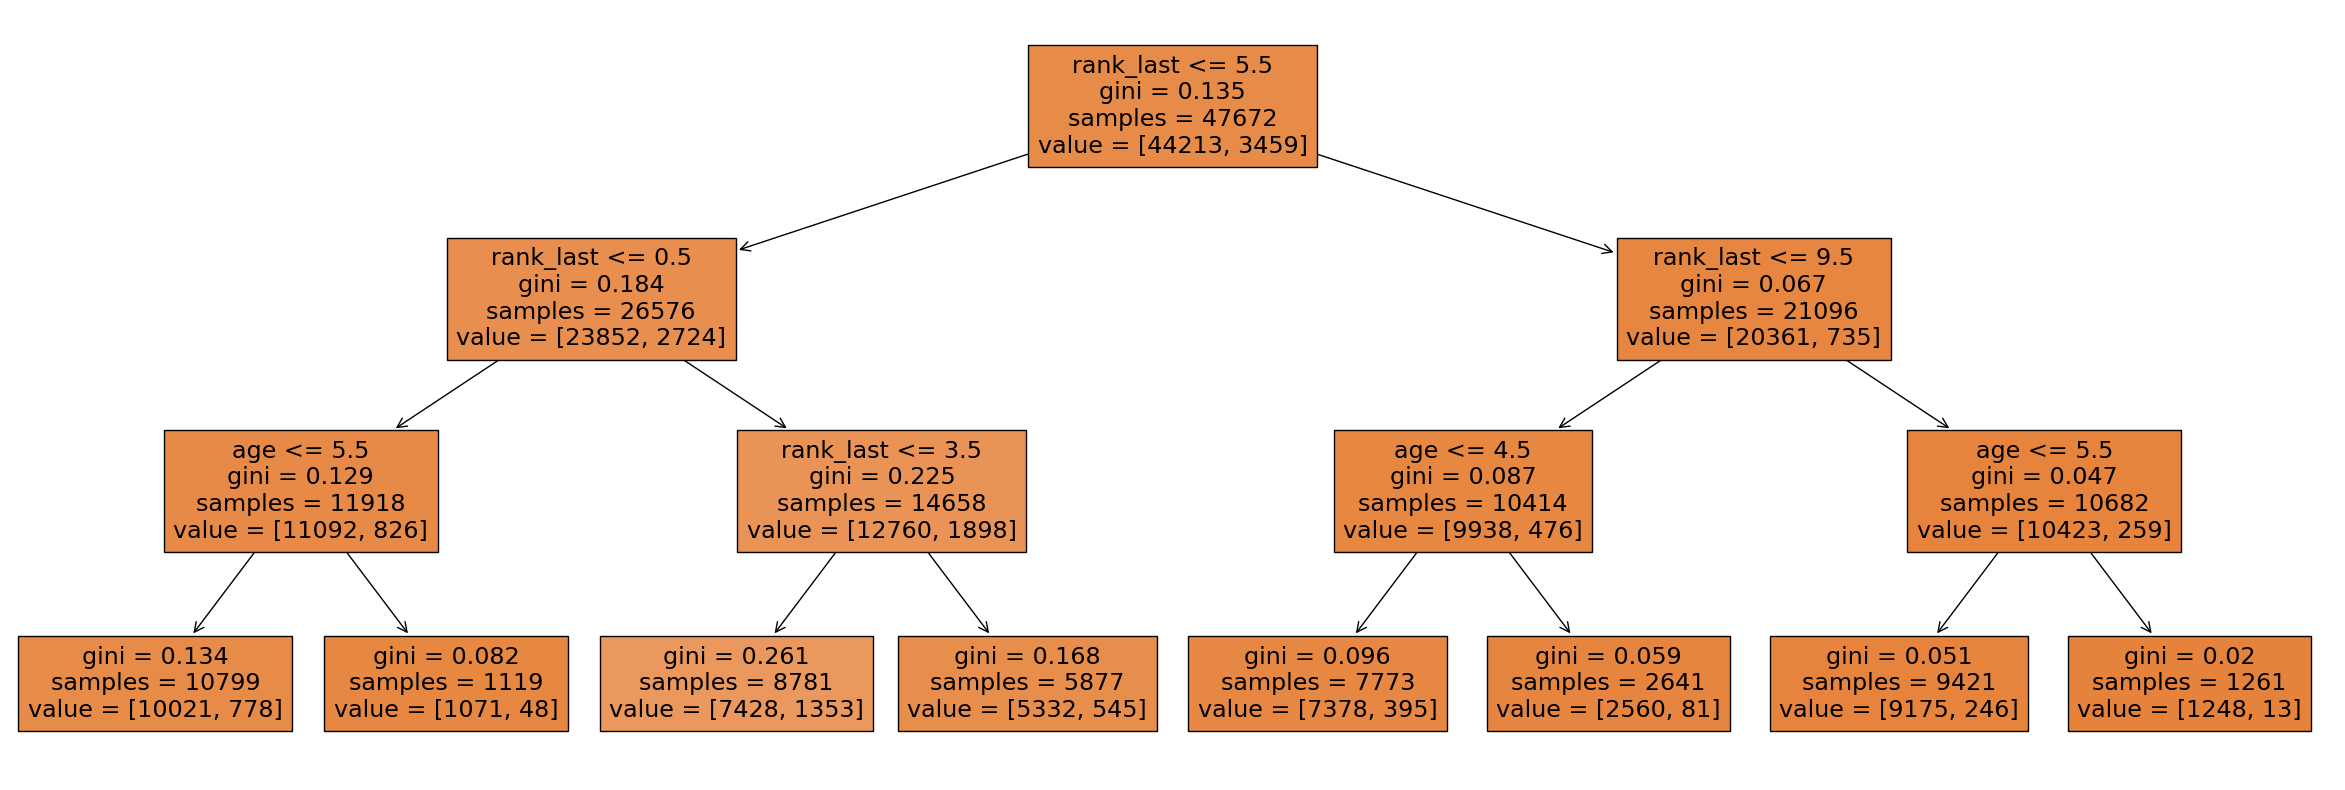

In [ ]:
# scikit-learn 0.21以降から実装された
fig = plt.figure(figsize=(30, 10))
ax = fig.add_subplot()
split_info = plot_tree(tree_model, feature_names=col_name, ax=ax, filled=True)

### Parameter Tuning：Cross Validation
 Cross Validationを利用してパラメータ(今回はmax_depthの例)をチューニングします.
  - シンプルにrandomでグループ分け：**本来はここをきちんと検証の枠組みとして考える必要がある**

In [ ]:
# 分割数
K = 5

# 再現性のためシードを固定
np.random.seed(17)

# グループ分け
train_x["cv_group"] = np.random.randint(0, K, train_x.shape[0])


# チューニング
train_auc = []
valid_auc = []
search_list = [3, 4, 5, 6, 7, 8, 9, 10]
for j in search_list:

    # Cross Validation
    train_score = []
    valid_score = []

    for i in range(K):
        # 構築, 検証に分ける
        train_tmp_index = train_x[train_x["cv_group"] != i].drop("cv_group", axis = 1).index
        valid_tmp_index = train_x[train_x["cv_group"] == i].drop("cv_group", axis = 1).index

        train_x_tmp = train_x.loc[train_tmp_index]
        train_y_tmp = train_y.loc[train_tmp_index]

        valid_x_tmp = train_x.loc[valid_tmp_index]
        valid_y_tmp = train_y.loc[valid_tmp_index]

        # Make Model
        tree_model_tmp = DecisionTreeClassifier(
            criterion = "gini",                # Entropy基準の場合は"entropy”
            splitter = "best",                 # 分割をランダムで行う場合は"random"
            random_state=17,                   # 同じ分割スコアの時にランダムに選ぶseedを固定
            max_depth = j,                     # 決定木の深さの最大値
            min_samples_split = 500,           # 分割する最小データ数
            min_samples_leaf = 100             # 末端ノードに該当する最小サンプル数
        )
        tree_model = tree_model_tmp.fit(train_x_tmp, train_y_tmp)

        # 構築データのAUC
        pred = tree_model_tmp.predict_proba(train_x_tmp)[:, 1]
        train_score.append(roc_auc_score(train_y_tmp, pred))

        # 検証データのAUC
        pred = tree_model_tmp.predict_proba(valid_x_tmp)[:, 1]
        valid_score.append(roc_auc_score(valid_y_tmp, pred))

    train_auc.append(sum(train_score) / K)
    valid_auc.append(sum(valid_score) / K)

del train_x["cv_group"]

### Check Overfit
 過学習の確認.

In [ ]:
g_train = pd.DataFrame(
    np.array([search_list, train_auc]).T,
    columns = ["Search", "AUC"]
)
g_train["Data"] = "train"

g_valid = pd.DataFrame(
    np.array([search_list, valid_auc]).T,
    columns = ["Search", "AUC"]
)
g_valid["Data"] = "valid"

g_dat = pd.concat([g_train, g_valid])

[(0.5, 1.0)]

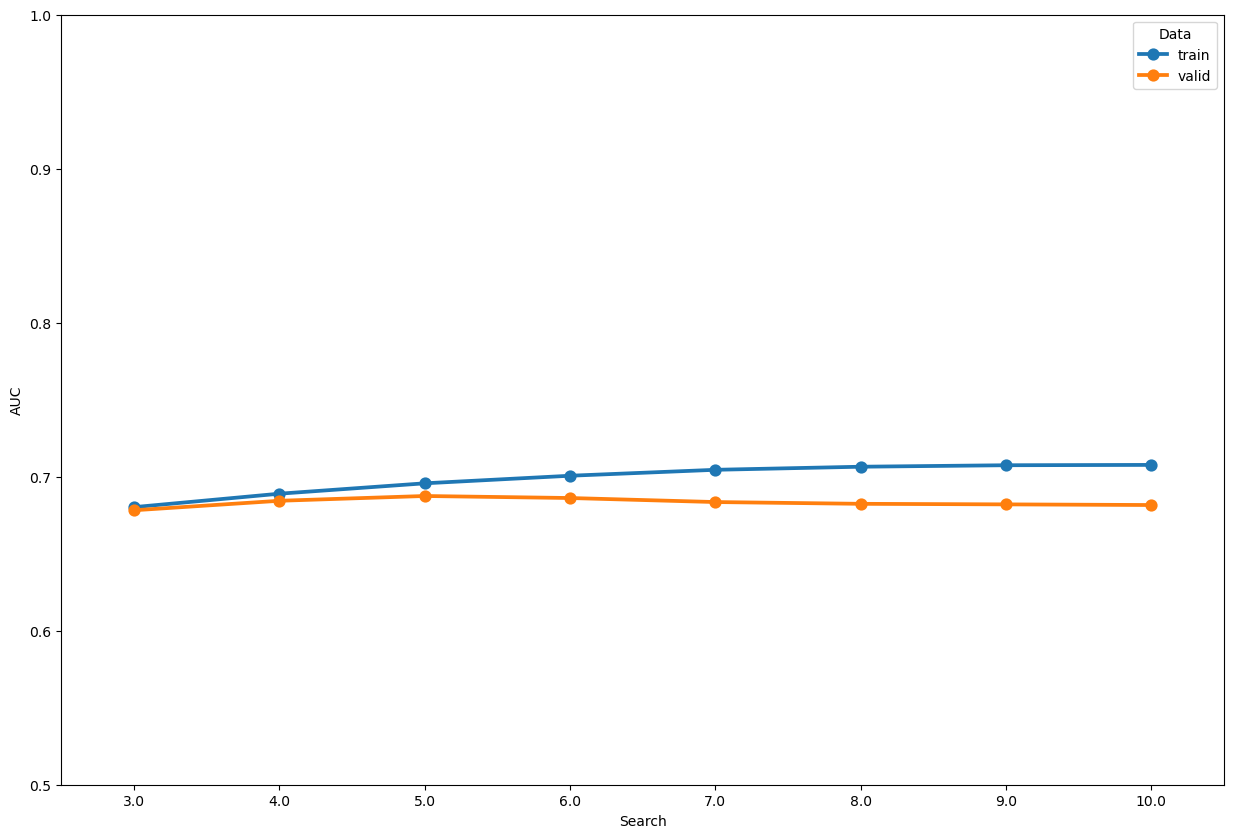

In [ ]:
sns.pointplot(
    data = g_dat,
    x = "Search",
    y = "AUC",
    hue = "Data"
).set(ylim = (0.5, 1))

In [ ]:
g_dat

,Search,AUC,Data
0,3.0,0.680255,train
1,4.0,0.688977,train
2,5.0,0.695719,train
3,6.0,0.700637,train
4,7.0,0.704493,train
5,8.0,0.706495,train
6,9.0,0.707459,train
7,10.0,0.707674,train
0,3.0,0.678222,valid
1,4.0,0.684380,valid


validで最もAUCが高かったのがmax_depth=5. よってmax_depth=5でtrainデータ全体でモデル作成.

In [ ]:
tree_model = DecisionTreeClassifier(
    criterion="gini",            # Entropy基準の場合は"entropy”
    splitter="best",             # 分割をランダムで行う場合は"random"
    random_state=17,             # 同じ分割スコアの時にランダムに選ぶseedを固定
    max_depth=5,                 # 決定木の深さの最大値
    min_samples_split=500,       # 分割する最小データ数
    min_samples_leaf=100         # 末端ノードに該当する最小サンプル数
)
tree_model = tree_model.fit(train_x, train_y)

 検証データのAUCを確認.

In [ ]:
pred = tree_model.predict_proba(valid_x)[:, 1]
roc_auc_score(valid_y, pred)

0.6935345417401698

### Save Model

In [ ]:
# モデルを保存
joblib.dump(tree_model, "./model/decision_tree_model_20250821.pkl")

['./model/decision_tree_model_20250821.pkl']

## Simulation
 - 確率の一番高い馬に1000ポイント付与した場合のシミュレーションを行う

In [ ]:
# 予測確率の付与
valid["pred_prob"] = tree_model.predict_proba(valid_x)[:, 1]
valid[["year", "month", "day", "place", "race_num", "horse", "rank", "pred_prob"]].head(20)

,year,month,day,place,race_num,horse,rank,pred_prob
0,24,7,20,札幌,1,ルージュアマリア,4,0.154083
1,24,7,20,札幌,1,ニシノクードクール,2,0.154083
2,24,7,20,札幌,1,ロードヴェルト,3,0.154083
3,24,7,20,札幌,1,ロードヴァルカン,5,0.026112
4,24,7,20,札幌,1,ポッドベイダー,1,0.154083
5,24,7,20,札幌,2,ロマンスヒコー,11,0.050817
6,24,7,20,札幌,2,タミゼ,1,0.050817
7,24,7,20,札幌,2,コパマエチャン,6,0.092734
8,24,7,20,札幌,2,スリーボビー,7,0.026112
9,24,7,20,札幌,2,タイセイフォルテ,12,0.154083


In [ ]:
# 確率の高い馬がどうなっているか確認
valid.sort_values(["pred_prob"],ascending=False)[
    ["year", "month", "day", "place", "race_num", "horse", "rank", "pred_prob", "win_odds"]].head(20)

,year,month,day,place,race_num,horse,rank,pred_prob,win_odds
0,24,7,20,札幌,1,ルージュアマリア,4,0.154083,5.9
20978,24,3,2,中山,8,ウインルピナス,4,0.154083,6.7
20993,24,3,2,中山,9,ホウオウサンデー,7,0.154083,3.3
20997,24,3,2,中山,9,キントリヒ,1,0.154083,7.7
20998,24,3,2,中山,9,タガノバルコス,6,0.154083,22.6
21002,24,3,2,中山,10,ヴァンドゥラン,5,0.154083,13.5
21011,24,3,2,中山,10,タマモロック,9,0.154083,9.3
21013,24,3,2,中山,10,ミラクルティアラ,1,0.154083,1.7
21016,24,3,2,中山,11,ヨシノイースター,4,0.154083,14.0
21018,24,3,2,中山,11,グレイトゲイナー,7,0.154083,20.2


In [ ]:
# レースごとに一番確率の高い馬を抽出
bet_horse = valid.loc[
    valid.groupby(["year", "month", "day", "place", "race_num"])["pred_prob"].idxmax()].copy()

# 当たりフラグ作成
bet_horse["hit_flg"] = (bet_horse["rank"] == 1) + 0

# 時系列準に並び替えて, 必要な列に制限
bet_horse = bet_horse.sort_values(["race_id"])[
    ["year", "month", "day", "place", "race_num",
     "horse", "rank", "pred_prob", "hit_flg", "error_code", "win_odds"]].copy()

In [ ]:
bet_horse.shape

(3454, 11)

In [ ]:
# 確率の高い馬がどうなっているか確認
bet_horse.head(20)

,year,month,day,place,race_num,horse,rank,pred_prob,hit_flg,error_code,win_odds
19256,24,1,6,中山,1,ミッキードラマー,7,0.154083,0,0,7.8
19275,24,1,6,中山,2,ビーナスライズ,6,0.154083,0,0,10.8
19287,24,1,6,中山,3,ガラスノイチゴ,0,0.072044,0,1,NaN
19303,24,1,6,中山,4,ノアファラオ,9,0.072044,0,0,148.6
19319,24,1,6,中山,5,ジーティーオウジャ,7,0.154083,0,0,34.3
19336,24,1,6,中山,6,クロスザルビコン,8,0.154083,0,0,3.1
19354,24,1,6,中山,7,アララララ,2,0.154083,0,0,2.7
19366,24,1,6,中山,8,シンボリックレルム,10,0.154083,0,0,4.8
19381,24,1,6,中山,9,ビューティーウェイ,5,0.154083,0,0,6.7
19389,24,1,6,中山,10,キャプテンシー,1,0.154083,1,0,3.8


ガラスノイチゴがrank=0なのはerror_code=1で出走取消となった馬.
 - 出走取消(error_code=1)または競走除外(error_code=3)は返還されるので, Simulationから外す

In [ ]:
### Simulation
flat_bet = 1000
Bankroll = 100 * 10000
Bankroll_History = []
for idx, row in bet_horse.iterrows():
    # 出走取消(error_code=1)または競走除外(error_code=3)は除く
    if row.error_code in [1, 3]:
        continue
    # ポイントの増減
    Bankroll = Bankroll - flat_bet + flat_bet * row.win_odds * row.hit_flg
    Bankroll_History += [int(Bankroll)]

最終的なポイント：56800ポイント


<AxesSubplot:>

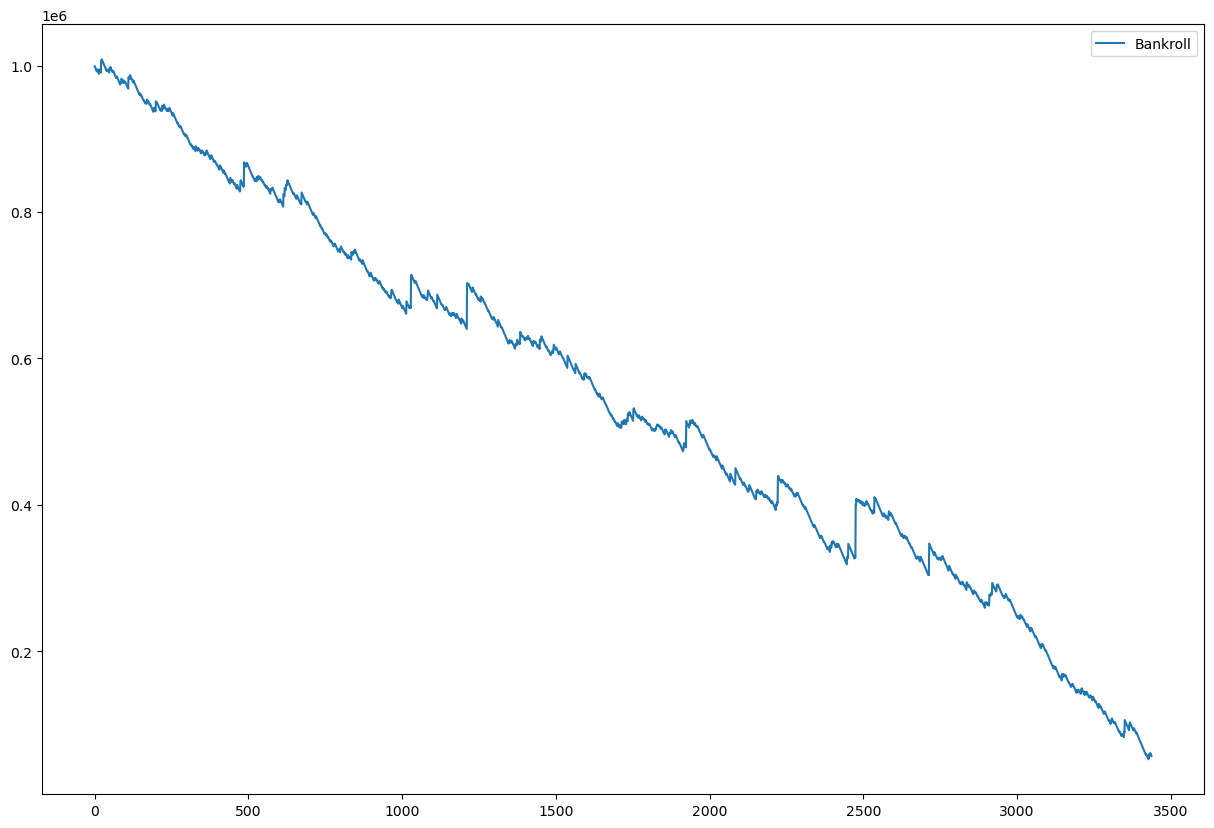

In [ ]:
dat_g = pd.DataFrame()
dat_g["Bankroll"] =  Bankroll_History
print("最終的なポイント：" + str(Bankroll_History[len(Bankroll_History)-1]) + "ポイント")
dat_g.plot()